In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


In [13]:
# ============================================================
# BLOCK 2: Load & Merge Monday + Friday DDoS
# ============================================================
import pandas as pd
import os

base_path = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"

files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
]

dfs = []
for file in files:
    path = os.path.join(base_path, file)
    df_temp = pd.read_csv(path, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    dfs.append(df_temp)
    print(f"Loaded {file}: {df_temp.shape}")

df = pd.concat(dfs, ignore_index=True)

print("\nFinal merged shape:", df.shape)
print("\nLabel distribution:\n", df['Label'].value_counts())

Loaded Monday-WorkingHours.pcap_ISCX.csv: (529918, 79)
Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (225745, 79)

Final merged shape: (755663, 79)

Label distribution:
 Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


In [14]:
df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [15]:
df.sample(10)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
317354,53,49579,2,2,78,360,39,39,39.000000,0.000000,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
194298,59795,78,1,1,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
2348,443,115179043,21,20,1143,6532,696,0,54.428571,154.475426,...,20,49030.181818,85677.109662,307356,23056,1.002821e+07,56825.382181,10086714,9900574,BENIGN
15849,123,69092743,2,2,96,96,48,48,48.000000,0.000000,...,20,92718.000000,0.000000,92718,92718,6.890734e+07,0.000000,68907345,68907345,BENIGN
674342,80,2336721,4,0,24,0,6,6,6.000000,0.000000,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,DDoS
493582,55605,26,1,1,0,0,0,0,0.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
634183,64447,11750992,1,6,6,36,6,6,6.000000,0.000000,...,20,30795.000000,0.000000,30795,30795,1.170000e+07,0.000000,11700000,11700000,BENIGN
103023,80,5618186,3,1,12,0,6,0,4.000000,3.464102,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
6898,53,776,2,2,112,276,56,56,56.000000,0.000000,...,32,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN
432111,53,30920,2,2,84,204,42,42,42.000000,0.000000,...,20,0.000000,0.000000,0,0,0.000000e+00,0.000000,0,0,BENIGN


In [16]:
print(df['Label'].value_counts())

Label
BENIGN    627636
DDoS      128027
Name: count, dtype: int64


In [17]:
df.columns = df.columns.str.strip()

In [18]:
cols_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']
df = df.drop(columns=cols_to_drop, errors='ignore')

In [19]:
import numpy as np

# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop missing values
df.dropna(inplace=True)

print("After cleaning:", df.shape)

After cleaning: (755192, 79)


In [20]:
X = df.drop(columns=['Label'], errors='ignore')

In [21]:
X = X.select_dtypes(include=[np.number])
print("Feature shape:", X.shape)

Feature shape: (755192, 78)


In [22]:
X_original = X.copy()

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
print("NaNs in scaled data:", np.isnan(X_scaled).sum())

NaNs in scaled data: 0


In [25]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # assume ~5% anomalies
    random_state=42,
    n_jobs=-1
)

iso_labels = iso.fit_predict(X_scaled)

In [26]:
scores = iso.decision_function(X_scaled)

In [27]:
import numpy as np

total = len(iso_labels)
anomalies = np.sum(iso_labels == -1)

print("Total samples:", total)
print("Anomalies detected:", anomalies)
print("Anomaly percentage:", anomalies / total)

Total samples: 755192
Anomalies detected: 37687
Anomaly percentage: 0.049903865507049866


In [28]:
X_anomaly_scaled = X_scaled[iso_labels == -1]
X_anomaly_original = X_original.iloc[iso_labels == -1]

print("Anomaly dataset shape:", X_anomaly_scaled.shape)

Anomaly dataset shape: (37687, 78)


In [29]:
df['anomaly_label'] = iso_labels
df['anomaly_score'] = scores
df_anomaly = df[df['anomaly_label'] == -1]

print(df_anomaly.shape)

(37687, 81)


In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=15, random_state=42)

X_pca = pca.fit_transform(X_anomaly_scaled)

print("PCA shape:", X_pca.shape)

PCA shape: (37687, 15)


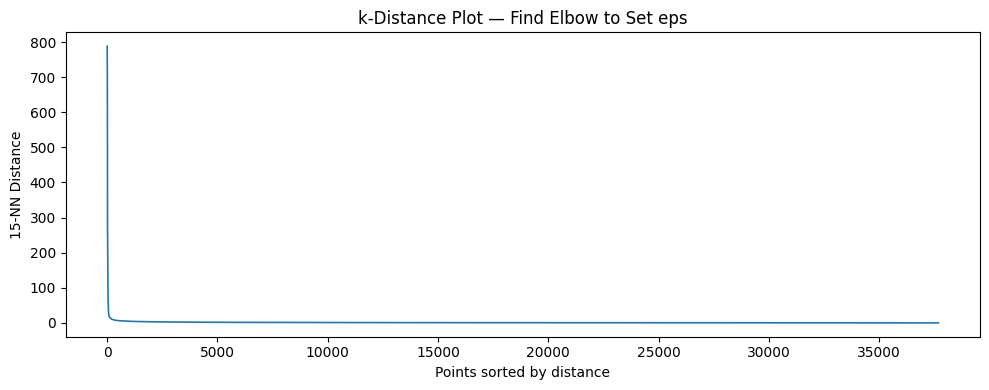

In [31]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
# Set min_samples (rule: ~2 × PCA dims → 15 → use 15 or 20)
MIN_SAMPLES = 15

# Fit nearest neighbors
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES, n_jobs=-1)
nn.fit(X_pca)

# Get distances
distances, _ = nn.kneighbors(X_pca)

# Take the farthest neighbor distance
k_distances = np.sort(distances[:, -1])[::-1]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=1.2)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{MIN_SAMPLES}-NN Distance")
plt.title("k-Distance Plot — Find Elbow to Set eps")
plt.tight_layout()
plt.show()

In [32]:
eps_value = 1.5   # based on your elbow (~0.5–1.0 range)
MIN_SAMPLES = 15
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=eps_value, min_samples=MIN_SAMPLES, n_jobs=-1)
db_labels = db.fit_predict(X_pca)

In [33]:
import numpy as np

unique_labels = set(db_labels)

num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
noise_points = np.sum(db_labels == -1)

print("Unique labels:", unique_labels)
print("Number of clusters:", num_clusters)
print("Noise points:", noise_points)

Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(-1)}
Number of clusters: 51
Noise points: 4538


In [34]:
df_anomaly = df[df['anomaly_label'] == -1].copy()
df_anomaly['cluster'] = db_labels

In [35]:
print(df_anomaly['cluster'].value_counts())

cluster
 32    6162
 1     5121
-1     4538
 34    4167
 0     3844
 31    2991
 37    2745
 3     1341
 33     858
 40     657
 2      577
 35     564
 49     506
 5      400
 11     320
 39     306
 6      298
 28     292
 42     291
 14     187
 17     113
 4      109
 7      105
 13     103
 10     100
 36      98
 16      96
 41      63
 22      63
 19      57
 46      54
 30      54
 9       47
 15      37
 18      37
 23      35
 43      34
 20      32
 45      31
 50      30
 12      26
 44      25
 21      23
 24      19
 27      19
 8       19
 47      19
 38      18
 29      15
 25      15
 48      15
 26      11
Name: count, dtype: int64


In [36]:
import pandas as pd
print(pd.crosstab(df_anomaly['cluster'], df_anomaly['Label']))

Label    BENIGN  DDoS
cluster              
-1         4536     2
 0         3844     0
 1         5121     0
 2          577     0
 3         1341     0
 4          109     0
 5          400     0
 6          298     0
 7          105     0
 8           19     0
 9           47     0
 10         100     0
 11         320     0
 12          26     0
 13         103     0
 14         187     0
 15          37     0
 16          96     0
 17         113     0
 18          37     0
 19          57     0
 20          32     0
 21          23     0
 22          63     0
 23          35     0
 24          19     0
 25          15     0
 26          11     0
 27          19     0
 28         292     0
 29          15     0
 30          54     0
 31           0  2991
 32           0  6162
 33         858     0
 34        4167     0
 35         564     0
 36          98     0
 37        2745     0
 38          18     0
 39         306     0
 40         657     0
 41          63     0
 42       

In [37]:
# ---- Improvement: focus on meaningful clusters ----

cluster_counts = df_anomaly['cluster'].value_counts()

# Keep only large clusters (you can tune threshold)
large_clusters = cluster_counts[cluster_counts > 500].index

df_filtered = df_anomaly[df_anomaly['cluster'].isin(large_clusters)]

print("Filtered cluster distribution:")
print(df_filtered['cluster'].value_counts())

Filtered cluster distribution:
cluster
 32    6162
 1     5121
-1     4538
 34    4167
 0     3844
 31    2991
 37    2745
 3     1341
 33     858
 40     657
 2      577
 35     564
 49     506
Name: count, dtype: int64


In [38]:
attack_clusters = [31, 32]

df_attacks = df_anomaly[df_anomaly['cluster'].isin(attack_clusters)]

print(df_attacks.shape)

(9153, 82)


In [39]:
df_attacks.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,anomaly_label,anomaly_score,cluster
count,9153.0,9.153000e+03,9153.000000,9153.000000,9153.000000,9153.000000,9153.0,9153.0,9153.000000,9153.000000,...,9153.0,9.153000e+03,9.153000e+03,9.153000e+03,9.153000e+03,9.153000e+03,9.153000e+03,9153.0,9153.000000,9153.000000
mean,80.0,8.940789e+07,8.176226,4.677701,57.051459,11604.024254,20.0,0.0,6.980290,5.596887,...,0.0,1.874985e+06,1.874985e+06,7.191661e+07,1.740907e+07,8.422600e+07,5.960633e+07,-1.0,-0.019381,31.673222
std,0.0,9.263138e+06,0.432602,0.765802,2.621371,29.816980,0.0,0.0,0.055891,0.168404,...,0.0,1.733443e+06,1.733443e+06,1.993889e+07,2.533986e+07,9.387874e+06,3.673018e+07,0.0,0.014916,0.469061
min,80.0,7.005906e+07,5.000000,3.000000,32.000000,8766.000000,20.0,0.0,6.250000,5.006662,...,0.0,0.000000e+00,0.000000e+00,3.460000e+07,0.000000e+00,5.810000e+07,5.002907e+06,-1.0,-0.067113,31.000000
25%,80.0,8.122443e+07,8.000000,4.000000,56.000000,11601.000000,20.0,0.0,7.000000,5.656854,...,0.0,2.298000e+03,2.298000e+03,4.950000e+07,0.000000e+00,7.680000e+07,9.955799e+06,-1.0,-0.028337,31.000000
50%,80.0,9.093776e+07,8.000000,5.000000,56.000000,11607.000000,20.0,0.0,7.000000,5.656854,...,0.0,1.918022e+06,1.918022e+06,7.700000e+07,0.000000e+00,8.580000e+07,7.700000e+07,-1.0,-0.015821,32.000000
75%,80.0,9.791228e+07,8.000000,5.000000,56.000000,11607.000000,20.0,0.0,7.000000,5.656854,...,0.0,3.599520e+06,3.599520e+06,8.930000e+07,4.770000e+07,9.200000e+07,8.930000e+07,-1.0,-0.007345,32.000000
max,80.0,1.039416e+08,10.000000,8.000000,68.000000,11607.000000,20.0,0.0,7.600000,8.173127,...,0.0,4.998828e+06,4.998828e+06,1.010000e+08,6.430000e+07,1.010000e+08,1.010000e+08,-1.0,-0.000002,32.000000


In [40]:
df_anomaly.groupby('cluster').mean(numeric_only=True).loc[[31, 32]]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,anomaly_label,anomaly_score
cluster,,,,,,,,,,,,,,,,,,,,,
31,80.0,9.213353e+07,8.169174,4.384152,57.013039,11604.667001,20.0,0.0,6.981805,5.599462,...,1.938297e+03,0.0,1.938297e+03,1.938297e+03,4.572966e+07,5.327489e+07,8.339863e+07,8.057974e+06,-1.0,-0.019142
32,80.0,8.808489e+07,8.179649,4.820188,57.070107,11603.712269,20.0,0.0,6.979554,5.595638,...,2.784151e+06,0.0,2.784151e+06,2.784151e+06,8.462760e+07,0.000000e+00,8.462760e+07,8.462760e+07,-1.0,-0.019497


In [42]:
from sklearn.ensemble import RandomForestClassifier

# ❗ Remove noise points (-1) before training
mask = db_labels != -1

# Train on only valid clusters
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_anomaly_scaled[mask], db_labels[mask])

print("✅ Random Forest Classifier trained successfully (noise removed)!")

✅ Random Forest Classifier trained successfully (noise removed)!


In [43]:
df_anomaly['pred_cluster'] = clf.predict(X_anomaly_scaled)

In [46]:
def get_cluster_label(cluster, series):
    # Force noise to Unknown
    if cluster == -1:
        return "Unknown"
    
    # Remove benign
    filtered = series[series != "BENIGN"]
    
    if len(filtered) == 0:
        return "Unknown"
    
    return filtered.value_counts().idxmax()


cluster_map = {
    cluster: get_cluster_label(cluster, group)
    for cluster, group in df_anomaly.groupby('cluster')['Label']
}

print("Final Cluster Mapping:", cluster_map)

Final Cluster Mapping: {-1: 'Unknown', 0: 'Unknown', 1: 'Unknown', 2: 'Unknown', 3: 'Unknown', 4: 'Unknown', 5: 'Unknown', 6: 'Unknown', 7: 'Unknown', 8: 'Unknown', 9: 'Unknown', 10: 'Unknown', 11: 'Unknown', 12: 'Unknown', 13: 'Unknown', 14: 'Unknown', 15: 'Unknown', 16: 'Unknown', 17: 'Unknown', 18: 'Unknown', 19: 'Unknown', 20: 'Unknown', 21: 'Unknown', 22: 'Unknown', 23: 'Unknown', 24: 'Unknown', 25: 'Unknown', 26: 'Unknown', 27: 'Unknown', 28: 'Unknown', 29: 'Unknown', 30: 'Unknown', 31: 'DDoS', 32: 'DDoS', 33: 'Unknown', 34: 'Unknown', 35: 'Unknown', 36: 'Unknown', 37: 'Unknown', 38: 'Unknown', 39: 'Unknown', 40: 'Unknown', 41: 'Unknown', 42: 'Unknown', 43: 'Unknown', 44: 'Unknown', 45: 'Unknown', 46: 'Unknown', 47: 'Unknown', 48: 'Unknown', 49: 'Unknown', 50: 'Unknown'}


In [47]:
def generate_alert(cluster):
    attack = cluster_map.get(cluster, "Unknown")
    attack_lower = str(attack).lower()

    if cluster == -1:
        return "⚠️ Unknown Threat (Noise)"

    if "ddos" in attack_lower or "dos" in attack_lower:
        return "🚨 DDoS Attack"
    elif attack == "Unknown":
        return "⚠️ Suspicious Activity"
    elif "port" in attack_lower:
        return "🔍 Port Scan"
    elif "bot" in attack_lower:
        return "🤖 Bot Activity"
    else:
        return f"⚠️ {attack} Activity"

In [49]:
df_anomaly['Alert_Type'] = df_anomaly['pred_cluster'].apply(generate_alert)

In [50]:
# 1. Train Random Forest (ignoring noise)
mask = db_labels != -1
clf.fit(X_anomaly_scaled[mask], db_labels[mask])

# 2. Get Predictions for ALL anomalies
df_anomaly['pred_cluster'] = clf.predict(X_anomaly_scaled)

# 3. Create the Alert_Type column (Run this BEFORE sampling!)
df_anomaly['Alert_Type'] = df_anomaly['pred_cluster'].apply(generate_alert)

# 4. Save Models & Mapping
import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(iso, 'isolation_forest.pkl')
joblib.dump(clf, 'random_forest.pkl')
joblib.dump(cluster_map, 'cluster_map.pkl')  

# 5. Safe Sampling Step
benign_sample = df[df['Label'] == 'BENIGN'].sample(200, random_state=42)
ddos_sample = df_anomaly[df_anomaly['Alert_Type'] == '🚨 DDoS Attack']
ddos_sample = ddos_sample.sample(min(100, len(ddos_sample)), random_state=42)

# 6. Save the Sample Dataset
sample_df = pd.concat([benign_sample, ddos_sample])
sample_df.to_csv('sample_network_traffic.csv', index=False)

print("Export complete!")


Export complete!


In [51]:
import os
print(os.getcwd())
print(os.listdir())

/kaggle/working
['.virtual_documents', 'scaler.pkl', 'sample_network_traffic.csv', 'random_forest.pkl', 'cluster_map.pkl', 'isolation_forest.pkl']
